In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as  sns
import mysql.connector
import numpy as np

In [3]:
db = mysql.connector.connect(host ='localhost',
                             username='root',
                             password='password',
                             database='ecommers')
cur = db.cursor()

# List all unique cities where customer are located

In [8]:
querry = """ select distinct customer_city from customers"""

cur.execute(querry)

data = cur.fetchall()

df = pd.DataFrame(data)
df

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
...,...
4114,siriji
4115,natividade da serra
4116,monte bonito
4117,sao rafael


# Count the numbers of orders placed in 2017

In [5]:
querry = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """

cur.execute(querry)

data = cur.fetchall()

"total orders place in 2017 are", data[0][0]

('total orders place in 2017 are', 90202)

# Find the total sales per category

In [9]:
query = """ select upper(products.product_category) category, 
round(sum(payments.payment_value),2) sales
from products join order_items 
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by category
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data , columns = ["Category", "Sales"])
df

,Category,Sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


#  Calculate the percentage of orders that were paid in installments.

In [12]:
query = """select sum(case when payment_installments >= 1 then 1
            else 0 end ) / count(*) * 100
            from payments"""

cur.execute(query)

data = cur.fetchall()

"the percentage of orders that were paid in installments is", data[0][0]

('the percentage of orders that were paid in installments is',
 Decimal('99.9981'))

# Count the number of customers from each state

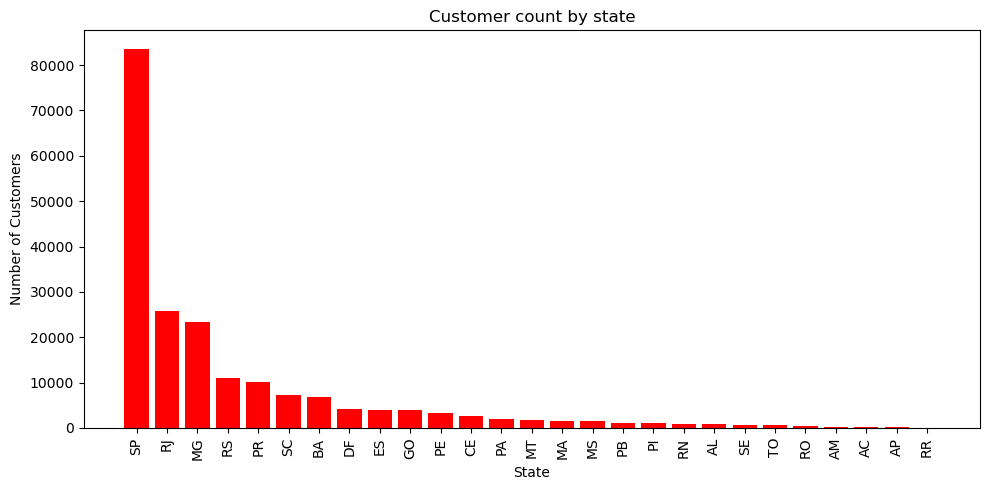

In [28]:
query = """ select customer_state, count(customer_id)
            from customers group by customer_state"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data , columns = ['state','customer_count'])
df = df.sort_values(by = 'customer_count', ascending=False)


plt.figure(figsize=(10,5))
plt.bar(df['state'], df['customer_count'], color='red')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.title('Customer count by state')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
